In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

# Implementing a KNN on the MNIST dataset
Using 784 features mnist ds. 

Download dataset,

In [246]:
mnist = fetch_openml("mnist_784", as_frame=False)

Split into train and test,

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    mnist.data, mnist.target, test_size=0.33, random_state=42
)

We need to augment the dataset as the user ll never exactly have the same angle for each photo capture,

In [ ]:
# This part have been generated using Claude AI.

rng = np.random.default_rng(42)


def random_affine(
    img, max_angle=15, max_shear=0.3, scale_range=(0.9, 1.1), max_shift=2
):
    """Random rotation, scaling, shear and shift around the image center."""
    angle = rng.uniform(-max_angle, max_angle)
    scale = rng.uniform(*scale_range)
    R = np.vstack([cv2.getRotationMatrix2D((14, 14), angle, scale), [0, 0, 1]])

    shear = rng.uniform(-max_shear, max_shear)
    S = np.array(
        [
            [1, shear, -shear * 14],  # horizontal shear, centered vertically
            [0, 1, 0],
            [0, 0, 1],
        ]
    )

    A = (S @ R)[:2]
    A[:, 2] += rng.uniform(-max_shift, max_shift, 2)
    return cv2.warpAffine(
        img, A.astype(np.float32), (28, 28), flags=cv2.INTER_LINEAR, borderValue=0
    )


def elastic(img, alpha=34, sigma=4):
    """Elastic deformation (Simard et al., 2003): smooth random displacement field."""
    dx = (
        cv2.GaussianBlur(rng.uniform(-1, 1, (28, 28)).astype(np.float32), (0, 0), sigma)
        * alpha
    )
    dy = (
        cv2.GaussianBlur(rng.uniform(-1, 1, (28, 28)).astype(np.float32), (0, 0), sigma)
        * alpha
    )
    x, y = np.meshgrid(np.arange(28, dtype=np.float32), np.arange(28, dtype=np.float32))
    return cv2.remap(img, x + dx, y + dy, cv2.INTER_LINEAR, borderValue=0)


def augment_dataset(X, y, copies=1, p_elastic=0.5):
    """Return the original data plus `copies` distorted versions of every image."""
    X_aug, y_aug = [X], [y]
    for _ in range(copies):
        out = np.empty_like(X, dtype=np.uint8)
        for i, row in enumerate(X):
            img = row.reshape(28, 28).astype(np.uint8)
            img = random_affine(img)
            if rng.random() < p_elastic:
                img = elastic(img)
            out[i] = img.ravel()
        X_aug.append(out)
        y_aug.append(y)
    return np.concatenate(X_aug), np.concatenate(y_aug)

In [249]:
X_train_aug, y_train_aug = augment_dataset(X_train, y_train, copies=1)

Implement and train k-NN,

In [ ]:
knn = make_pipeline(
    Normalizer(), KNeighborsClassifier(n_neighbors=6, weights="distance")
)

In [251]:
knn.fit(X_train_aug, y_train_aug)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('normalizer', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](10,)","['0','1','2',...,'7','8','9']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,784
,"norm norm: {'l1', 'l2', 'max'}, default='l2'The norm to use to normalize each non zero sample. If norm='max'is used, values will be rescaled by the maximum of the absolutevalues.",'l2'
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array or a scipy.sparseCSR matrix).",True
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,784


In [ ]:
result = knn.predict(X_test)

Evaluate the ds, 

In [ ]:
print("Accuracy :", accuracy_score(y_test, result))
print(classification_report(y_test, result))

Accuracy : 0.9771861471861472
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      2267
           1       0.97      0.99      0.98      2603
           2       0.99      0.97      0.98      2350
           3       0.98      0.97      0.98      2383
           4       0.99      0.97      0.98      2144
           5       0.99      0.97      0.98      2107
           6       0.98      0.99      0.99      2294
           7       0.97      0.98      0.98      2455
           8       0.98      0.96      0.97      2196
           9       0.95      0.97      0.96      2301

    accuracy                           0.98     23100
   macro avg       0.98      0.98      0.98     23100
weighted avg       0.98      0.98      0.98     23100



# Pipeline from raw image to prediction
Claude AI, have been used in this part mainly for the displaying of the samples. Inspired by these two articles: [https://www.mindee.com/blog/digit-recognition-python-opencv](https://www.mindee.com/blog/digit-recognition-python-opencv) and [https://docs.opencv.org/4.13.0/d8/d4b/tutorial_py_knn_opencv.html](https://docs.opencv.org/4.13.0/d8/d4b/tutorial_py_knn_opencv.html)

In [254]:
import cv2

In [255]:
# src: https://www.reddit.com/r/Handwriting/comments/zxjehf/i_have_always_struggled_with_my_fives_are_numbers/
reddit_sample = "./samples/randomsamplefromreddit.png"

In [256]:
def load_image_in_grayscale(path, target_width=1000):
    """
    Load an image from its path, convert it to grayscale and resize it to a fixed width
    """
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Impossible to load image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    scale = target_width / img.shape[1]
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    return cv2.resize(img, None, fx=scale, fy=scale, interpolation=interp)

In [257]:
grayscale = load_image_in_grayscale(reddit_sample)

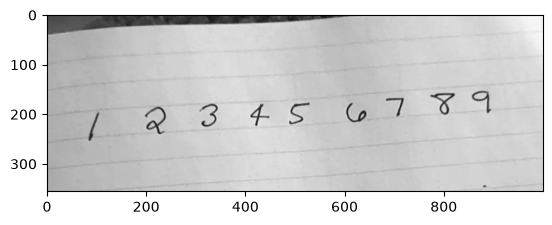

In [258]:
plt.imshow(grayscale, cmap="gray")

Reduce noise using gaussian blur,

In [259]:
def add_blur_on_image(img):
    return cv2.GaussianBlur(img, (9, 9), 0)

In [260]:
blurred = add_blur_on_image(grayscale)

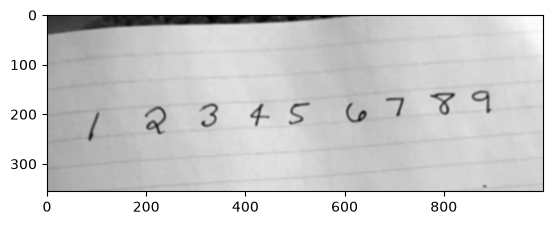

In [261]:
plt.imshow(blurred, cmap="gray")

Binarise the image,

In [262]:
def binarize(img):
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return binary

In [263]:
binary = binarize(blurred)

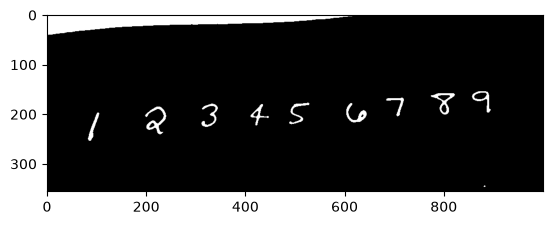

In [264]:
plt.imshow(binary, cmap="gray")

Dilate image to fill spaces, 

In [265]:
def dilate(img):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    return cv2.dilate(img, kernel, iterations=2)

In [266]:
dilated = dilate(binary)

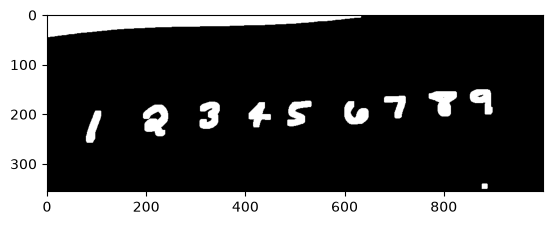

In [267]:
plt.imshow(dilated, cmap="gray")

Find contours, 

In [ ]:
def find_contours(img):
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        raise ValueError("No numbers on the image.")

    return contours

In [ ]:
def find_bounding_boxes(contours, min_area=200):
    boxes = []
    for c in contours:
        if cv2.contourArea(c) <= min_area:
            continue  # too small: noise
        x, y, w, h = cv2.boundingRect(c)
        if w >= 2 * h:
            continue  # at least twice as wide as tall: not a digit
        boxes.append((x, y, w, h))

    boxes.sort(key=lambda b: (b[1] // 50, b[0]))

    return boxes

In [270]:
contours = find_contours(dilated)
boxes = find_bounding_boxes(contours)

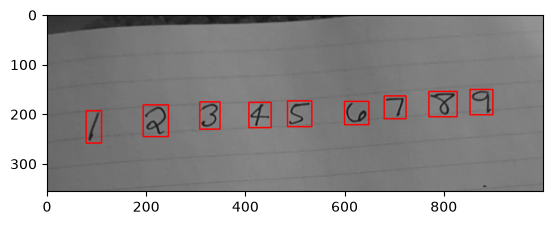

In [ ]:
vis = cv2.cvtColor(grayscale, cv2.COLOR_GRAY2RGB)
for x, y, w, h in boxes:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.imshow(vis)

Extract samples from the image and transform in MNIST 28x28 shape, 

In [ ]:
# fully implemented using Claude
def to_mnist(d, stroke=0.0):
    """
    d:      crop with white ink on black background
    stroke: thickening relative to digit size (0 = none, try 0.03 to 0.08)
    """
    # 1. Tight crop around the ink, so padding no longer affects the scale
    ys, xs = np.nonzero(d)
    if len(xs) == 0:
        return np.zeros((28, 28), dtype=np.uint8)
    d = d[ys.min() : ys.max() + 1, xs.min() : xs.max() + 1]
    h, w = d.shape

    # 2. Optional thickening, proportional to the digit's size
    k = int(round(max(h, w) * stroke))
    if k > 0:
        d = cv2.dilate(d, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k)))
        d = np.pad(d, k)  # dilation can grow past the crop
        ys, xs = np.nonzero(d)
        d = d[ys.min() : ys.max() + 1, xs.min() : xs.max() + 1]
        h, w = d.shape

    # 3. Fit in 20x20, keeping aspect ratio
    scale = 20.0 / max(h, w)
    resized = cv2.resize(
        d,
        (max(1, round(w * scale)), max(1, round(h * scale))),
        interpolation=cv2.INTER_AREA,
    )

    # 4. Paste in the middle of a 28x28 canvas
    canvas = np.zeros((28, 28), dtype=np.uint8)
    rh, rw = resized.shape
    y_off, x_off = (28 - rh) // 2, (28 - rw) // 2
    canvas[y_off : y_off + rh, x_off : x_off + rw] = resized

    # 5. Shift so the center of mass sits at the center, like MNIST
    m = cv2.moments(canvas)
    if m["m00"] > 0:
        cx, cy = m["m10"] / m["m00"], m["m01"] / m["m00"]
        M = np.float32([[1, 0, 14 - cx], [0, 1, 14 - cy]])
        canvas = cv2.warpAffine(canvas, M, (28, 28))
    return canvas

In [ ]:
def extract_digits(img, boxes, pad=3):
    H, W = img.shape
    samples = []
    for x, y, w, h in boxes:
        x0, y0 = max(x - pad, 0), max(y - pad, 0)
        x1, y1 = min(x + w + pad, W), min(y + h + pad, H)
        samples.append((to_mnist(img[y0:y1, x0:x1]), (x, y, w, h)))

    return samples

In [274]:
samples = extract_digits(binary, boxes)

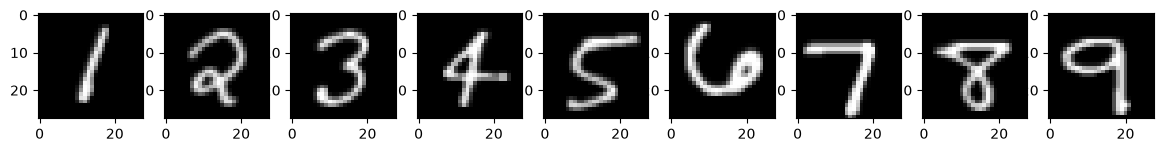

In [ ]:
n = len(samples)
fig, axes = plt.subplots(1, n, figsize=(1.6 * n, 2.2))
for ax, (digit, _) in zip(axes, samples, strict=False):
    ax.imshow(digit, cmap="gray")

Predict the digit,

In [ ]:
def predict_digit(digit, model):
    """
    digit: 28x28 uint8 image, white digit on black background
    Returns (prediction, {digit: probability})
    """
    x = digit.reshape(1, -1).astype(np.float32)
    probs = model.predict_proba(x)[0]
    pred = int(model.classes_[np.argmax(probs)])
    probabilities = {
        int(c): float(p) for c, p in zip(model.classes_, probs, strict=False)
    }
    return pred, probabilities

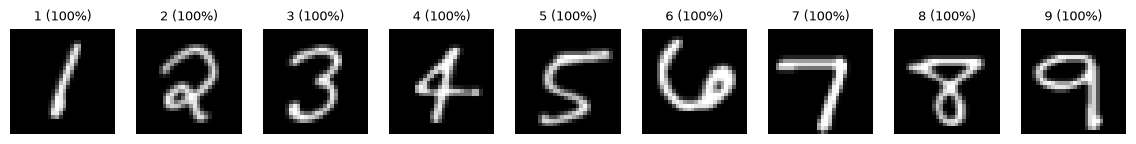

In [ ]:
results = []  # list of (prediction, probabilities, box)
for digit, box in samples:
    pred, probs = predict_digit(digit)
    results.append((pred, probs, box))

n = len(results)
fig, axes = plt.subplots(1, n, figsize=(1.6 * n, 2.2))
axes = np.atleast_1d(axes)
for ax, (digit, _), (pred, probs, _) in zip(axes, samples, results, strict=False):
    ax.imshow(digit, cmap="gray")
    ax.set_title(f"{pred} ({probs[pred]:.0%})", fontsize=9)
    ax.axis("off")
plt.show()

In [ ]:
def predict_in_image(path, model):
    grayscale = load_image_in_grayscale(path)
    blurred = add_blur_on_image(grayscale)
    binary = binarize(blurred)
    dilated = dilate(binary)
    contours = find_contours(dilated)
    boxes = find_bounding_boxes(contours)
    samples = extract_digits(binary, boxes)

    results = []
    for digit, box in samples:
        pred, probs = predict_digit(digit, model)
        results.append((pred, probs, box))

    return results, grayscale

In [282]:
results, grayscale = predict_in_image(path="./samples/handwrittendigits.jpg", model=knn)

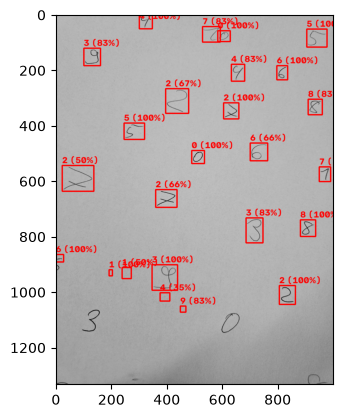

In [ ]:
vis = cv2.cvtColor(grayscale, cv2.COLOR_GRAY2RGB)

# Scale line and text size with the image, so they stay readable on large photos
s = max(vis.shape[:2]) / 1000
thickness = max(1, round(2 * s))

for pred, probs, (x, y, w, h) in results:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 0, 0), thickness)
    cv2.putText(
        vis,
        f"{pred} ({probs[pred]:.0%})",
        (x, max(y - 8, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8 * s,
        (255, 0, 0),
        thickness,
    )

plt.imshow(vis)

We can see on this last plot that we may improve the binarization and the defination of what is a digit and what is an artifact. For now we ll implement the current pipeline and look for improvement later.